# Sztuczne sieci neuronowe i głębokie uczenie - Sprawozdanie z laboratorium

## Temat:
Praca z modelem językowym HerBERT oraz porównanie metod reprezentacji tekstu.

### Cel ćwiczenia:
Celem laboratorium jest porównanie trzech podejść do przetwarzania tekstu w zadaniach NLP: klasycznego stemmingu, lematyzacji oraz nowoczesnych embeddingów kontekstowych opartych na architekturze Transformer (model HerBERT). Analiza przeprowadzana jest na polskim korpusie Allegro Reviews.

### Wykorzystane narzędzia:
Python 3, Jupyter Notebook. Biblioteki: `transformers`, `spacy` (pl_core_news_sm), `nltk`, `datasets`, `scikit-learn`, `pandas`, `matplotlib`, `seaborn`, `torch`.

In [7]:
import re
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datasets import load_dataset
import spacy
from transformers import AutoTokenizer, AutoModel
import torch
import random
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics.pairwise import cosine_similarity

dataset = load_dataset("allegro_reviews")
df_train = pd.DataFrame(dataset["train"])
df_train["sentiment"] = df_train["rating"].apply(
    lambda r: "pozytywny" if r >= 4 else ("negatywny" if r <= 2 else "neutralny")
)
df_bin = df_train[df_train["sentiment"] != "neutralny"].copy()

POLISH_STOPWORDS = set([
    "i", "w", "z", "na", "do", "się", "nie", "to", "że", "a", "jest", "jak", "ale", "po", 
    "czy", "przez", "co", "o", "za", "też", "już", "tak", "ten", "ta", "te", "go", "mu", 
    "je", "mi", "ma", "od", "przy", "dla", "lub", "być", "ze", "tej", "jej", "jego", "ich", 
    "by", "bo", "więc", "tylko", "jeszcze", "właśnie", "np", "tzw", "wiele", "bardzo", "wszystko"
])

def clean_text(text: str) -> str:
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", "", text)      
    text = re.sub(r"[^a-ząćęłńóśźżA-ZĄĆĘŁŃÓŚŹŻ\s]", " ", text)  
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_basic(text: str) -> list[str]:
    return [t for t in clean_text(text).split() if len(t) > 2]

def remove_stopwords(tokens: list[str]) -> list[str]:
    return [t for t in tokens if t not in POLISH_STOPWORDS]

class PolishStemmer:
    SUFFIXES = sorted([
        'zacja', 'zacji', 'ości', 'owie', 'ania', 'enie', 'ienia',
        'ami', 'ach', 'iem', 'om', 'ie', 'ią', 'ię',
        'ej', 'ym', 'im', 'ów', 'ę', 'ą', 'a', 'i', 'y', 'e', 'u',
    ], key=len, reverse=True)

    def stem(self, word: str) -> str:
        word = word.lower()
        for suffix in self.SUFFIXES:
            if word.endswith(suffix) and len(word) - len(suffix) >= 3:
                return word[:-len(suffix)]
        return word

stemmer = PolishStemmer()

nlp = spacy.load("pl_core_news_sm", disable=["parser", "ner"])
device = "cuda" if torch.cuda.is_available() else "cpu"
MODEL_NAME = "allegro/herbert-base-cased"
tokenizer_herbert = AutoTokenizer.from_pretrained(MODEL_NAME)
model_herbert = AutoModel.from_pretrained(MODEL_NAME).to(device)
model_herbert.eval()

def get_embedding(text: str) -> np.ndarray:
    inputs = tokenizer_herbert(text, return_tensors="pt", truncation=True, max_length=512, padding=True).to(device)
    with torch.no_grad():
        outputs = model_herbert(**inputs)
    hidden = outputs.last_hidden_state           
    mask = inputs["attention_mask"].unsqueeze(-1).float()
    embedding = (hidden * mask).sum(1) / mask.sum(1)  
    return embedding.squeeze().cpu().numpy()

vocab_raw = set(tok for text in df_bin["text"] for tok in tokenize_basic(text))

print("Gotowe! Środowisko i modele są załadowane.")

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 15466.24it/s]
BertModel LOAD REPORT from: allegro/herbert-base-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.decoder.weight             | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.sso.sso_relationship.bias              | UNEXPECTED |  | 
cls.sso.sso_relationship.weight            | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.decoder.bias               | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Gotowe! Środowisko i modele są załadowane.


### Zadanie 1: Stemming

**Komentarz:**
Stemming pozwala na szybką redukcję słów do rdzeni, nie wymagając przy tym słownika ani modelu językowego, jednak proces ten nie gwarantuje poprawności lingwistycznej. Przykłady błędnego lub zaskakującego działania stemmingu z naszego korpusu:
1. Słowo **,,miałam''** może zostać zredukowane do **,,miał''**, co traci informację o rodzaju gramatycznym.
2. Słowa o różnym zabarwieniu, np. **,,zadowolony''**, są ucinane do formy **,,zadowolon''**, co nie jest poprawnym polskim słowem.
3. Przecinanie zbyt wielu liter w krótkich słowach, co może prowadzić do zlania się pojęć o zupełnie różnym znaczeniu do tego samego krótkiego rdzenia (np. ,,kupiłem'' zredukowane do ,,kupił'').

In [8]:
random.seed(42)
sample_10 = df_bin['text'].sample(10, random_state=42).tolist()

task1_data = []
for sent in sample_10:
    tokens = remove_stopwords(tokenize_basic(sent))
    for tok in tokens:
        task1_data.append({
            "Token oryginalny": tok,
            "Stem (rdzeń)": stemmer.stem(tok)
        })

df_task1 = pd.DataFrame(task1_data)
print("Przykładowe tokeny i ich stemy z 10 losowych recenzji:")
display(df_task1.head(10))

vocab_raw = set(tok for text in df_bin["text"] for tok in tokenize_basic(text))
vocab_stem = set(stemmer.stem(tok) for tok in vocab_raw)

redukcja_stem = (1 - len(vocab_stem) / len(vocab_raw)) * 100
print(f"\nRozmiar słownika surowego: {len(vocab_raw)} typów")
print(f"Rozmiar słownika po stemmingu: {len(vocab_stem)} typów")
print(f"Stemming redukuje rozmiar słownika o: {redukcja_stem:.1f}%")

Przykładowe tokeny i ich stemy z 10 losowych recenzji:


,Token oryginalny,Stem (rdzeń)
0,dobre,dobr
1,szkło,szkło
2,które,któr
3,dzięki,dzięk
4,załączonej,załączon
5,nakładce,nakładc
6,sprawia,sprawi
7,montaż,montaż
8,ekranie,ekran
9,smartfonu,smartfon



Rozmiar słownika surowego: 48188 typów
Rozmiar słownika po stemmingu: 32539 typów
Stemming redukuje rozmiar słownika o: 32.5%


### Zadanie 2: Lematyzacja i porównanie słowników

**Komentarz:**
Lematyzacja w przeciwieństwie do stemmingu sprowadza słowo do jego poprawnej formy słownikowej, ponieważ uwzględnia kontekst gramatyczny za pomocą tagowania części mowy (POS). Lematyzacja daje wyraźnie lepsze wyniki niż stemming dla:
* **Czasowników w różnych formach koniugacji**, np. z korpusu: ,,kupiłem'' jest sprowadzane do ,,kupić być'' (lemat z czasownikiem posiłkowym), podczas gdy stemmer obcina to tylko do ,,kupił''.
* **Nieregularnych przymiotników i rzeczowników**, np. forma ,,tej'' sprowadzana jest poprawnie do lematu ,,ten'', podczas gdy stemmer pozostawia formę nieregularną bez zmian.
* **Złożonych końcówek deklinacyjnych**, gdzie lematyzacja zwraca mianownik liczby pojedynczej (np. ,,tygodnie'' -> ,,tydzień''), podczas gdy stemmer zwraca ,,tygodn''.

Porównanie tokenów, stemów i lematów:


,Token oryginalny,Stem (rdzeń),Lemat,POS
0,dobre,dobr,dobry,ADJ
1,szkło,szkło,szkło,NOUN
2,dzięki,dzięk,dzięki,ADP
3,załączonej,załączon,załączyć,ADJ
4,nakładce,nakładc,nakładka,NOUN
5,sprawia,sprawi,sprawiać,VERB
6,montaż,montaż,montaż,NOUN
7,ekranie,ekran,ekran,NOUN
8,smartfonu,smartfon,smartfon,NOUN
9,prosty,prost,prosty,ADJ



Obliczam lematy dla całego słownika.


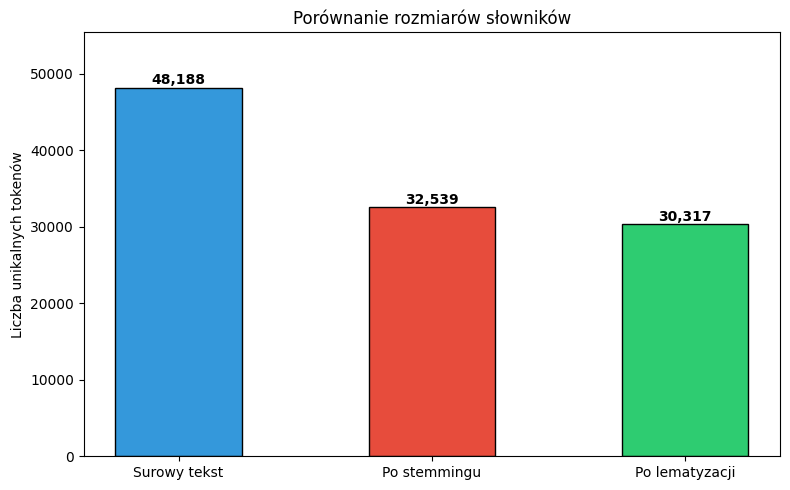

In [9]:
task2_data = []

task2_data = []
for sent in sample_10:
    doc = nlp(clean_text(sent))
    for token in doc:
        if not token.is_stop and not token.is_punct and len(token.lemma_) > 2:
            task2_data.append({
                "Token oryginalny": token.text,
                "Stem (rdzeń)": stemmer.stem(token.text),
                "Lemat": token.lemma_,
                "POS": token.pos_
            })

df_task2 = pd.DataFrame(task2_data)
print("Porównanie tokenów, stemów i lematów:")
display(df_task2.head(10))

print("\nObliczam lematy dla całego słownika.")
vocab_doc = nlp(" ".join(vocab_raw)) 
vocab_lemma = set(token.lemma_ for token in vocab_doc if not token.is_stop and not token.is_punct and len(token.lemma_) > 2)

fig, ax = plt.subplots(figsize=(8, 5))
methods = ["Surowy tekst", "Po stemmingu", "Po lematyzacji"]
sizes = [len(vocab_raw), len(vocab_stem), len(vocab_lemma)]
colors = ["#3498db", "#e74c3c", "#2ecc71"]

bars = ax.bar(methods, sizes, color=colors, width=0.5, edgecolor="black")
for bar, val in zip(bars, sizes):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500, f"{val:,}", ha="center", fontweight="bold")
    
ax.set_ylabel("Liczba unikalnych tokenów")
ax.set_title("Porównanie rozmiarów słowników")
ax.set_ylim(0, max(sizes) * 1.15)
plt.tight_layout()
plt.show()

### Zadanie 3: Trening i ocena klasyfikatorów

**Komentarz:**
Najlepszy wynik osiągnęła metoda bazująca na **surowym tekście (0.8793)**. W modelu TF-IDF bogactwo form gramatycznych (np. słowa silniej nacechowane emocjonalnie) często niesie dla algorytmu użyteczną informację. 
Różnica pomiędzy stemmingiem (0.8560) a lematyzacją (0.8459) nie jest bardzo duża, ale delikatnie wskazuje na korzyść stemmingu. Wynika to z faktu, że agresywne ucinanie końcówek w stemmingu drastycznie redukuje rzadkie słowa (out-of-vocabulary), co w prostych modelach (takich jak regresja logistyczna + TF-IDF) bywa korzystne.
Embeddingi HerBERT uzyskały na podzbiorze wynik 0.8500. Wynik ten jest bardzo dobry, zważywszy na to, że w przeciwieństwie do TF-IDF, model trenowano i testowano na zaledwie 200 recenzjach.

Przetwarzanie tekstów dla całego zbioru (stemming i lematyzacja).

Generowanie embeddingów HerBERT dla 200 recenzji...


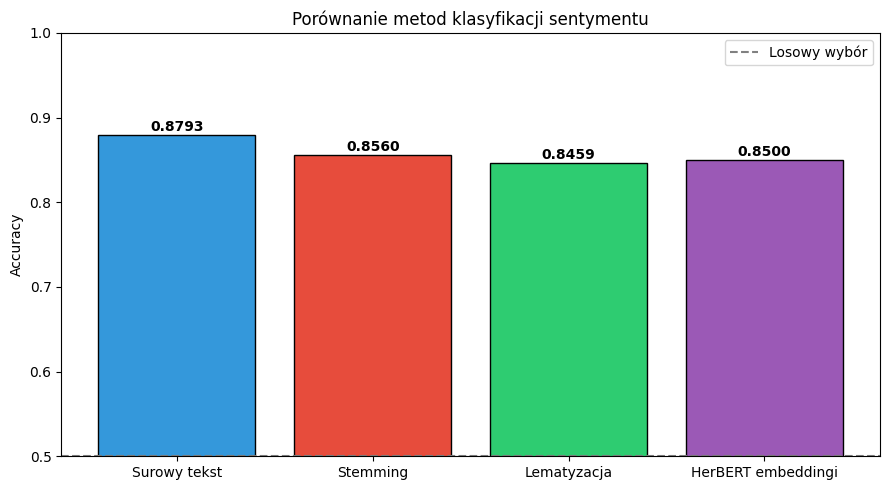

In [10]:
print("Przetwarzanie tekstów dla całego zbioru (stemming i lematyzacja).")
def stem_text(text):
    return " ".join([stemmer.stem(t) for t in remove_stopwords(tokenize_basic(text))])

def lemmatize_text(text):
    doc = nlp(clean_text(text))
    lemmas = [token.lemma_ for token in doc if not token.is_stop and not token.is_punct and len(token.lemma_) > 2]
    return " ".join(remove_stopwords(lemmas))

df_bin['stemmed_text'] = df_bin['text'].apply(stem_text)
df_bin['lemma_text'] = df_bin['text'].apply(lemmatize_text)

labels = (df_bin["sentiment"] == "pozytywny").astype(int).values
results = {}

methods_data = {
    "Surowy tekst": df_bin["text"].tolist(),
    "Stemming": df_bin["stemmed_text"].tolist(),
    "Lematyzacja": df_bin["lemma_text"].tolist()
}

for method_name, texts in methods_data.items():
    X_train, X_test, y_train, y_test = train_test_split(texts, labels, test_size=0.2, random_state=42, stratify=labels)
    pipe = Pipeline([
        ("tfidf", TfidfVectorizer(max_features=10000, ngram_range=(1, 2))),
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ])
    pipe.fit(X_train, y_train)
    results[method_name] = accuracy_score(y_test, pipe.predict(X_test))

print("\nGenerowanie embeddingów HerBERT dla 200 recenzji...")
pos = df_bin[df_bin["sentiment"] == "pozytywny"].sample(100, random_state=42)
neg = df_bin[df_bin["sentiment"] == "negatywny"].sample(100, random_state=42)
df_sample = pd.concat([pos, neg]).reset_index(drop=True)
labels_sample = (df_sample["sentiment"] == "pozytywny").astype(int).values

embeddings = np.array([get_embedding(text) for text in df_sample["text"]])

X_train_e, X_test_e, y_train_e, y_test_e = train_test_split(embeddings, labels_sample, test_size=0.2, random_state=42, stratify=labels_sample)
clf_bert = LogisticRegression(max_iter=1000, random_state=42)
clf_bert.fit(X_train_e, y_train_e)
results["HerBERT embeddingi"] = accuracy_score(y_test_e, clf_bert.predict(X_test_e))

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(results.keys(), results.values(), color=["#3498db", "#e74c3c", "#2ecc71", "#9b59b6"], edgecolor="black")
for bar, val in zip(bars, results.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005, f"{val:.4f}", ha="center", fontweight="bold")

ax.set_ylim(0.5, 1.0)
ax.set_ylabel("Accuracy")
ax.set_title("Porównanie metod klasyfikacji sentymentu")
ax.axhline(0.5, color="gray", linestyle="--", label="Losowy wybór")
ax.legend()
plt.tight_layout()
plt.show()

### Zadanie 4: Redukcja wymiarowości - PCA vs t-SNE

**Komentarz:**
Obie metody wizualizują wielowymiarowe embeddingi w 2D, jednak jak widać na załączonych wykresach, punkty obu klas (pozytywne i negatywne) silnie się ze sobą mieszają. 
Zjawisko to wynika z faktu, że użyliśmy ,,surowego'' (bazowego) modelu HerBERT. Taki model generuje embeddingi na podstawie ogólnej semantyki (tematu zdania) i jego struktury, a nie samego sentymentu. Zatem recenzja pozytywna i negatywna dotycząca tego samego przedmiotu znajdą się blisko siebie w przestrzeni wektorowej. PCA pokazuje bardziej zbite klastry maksymalizując globalną wariancję, podczas gdy t-SNE, próbując zachować lokalne sąsiedztwo, ,,rozrzuca'' te punkty szerzej na wykresie.

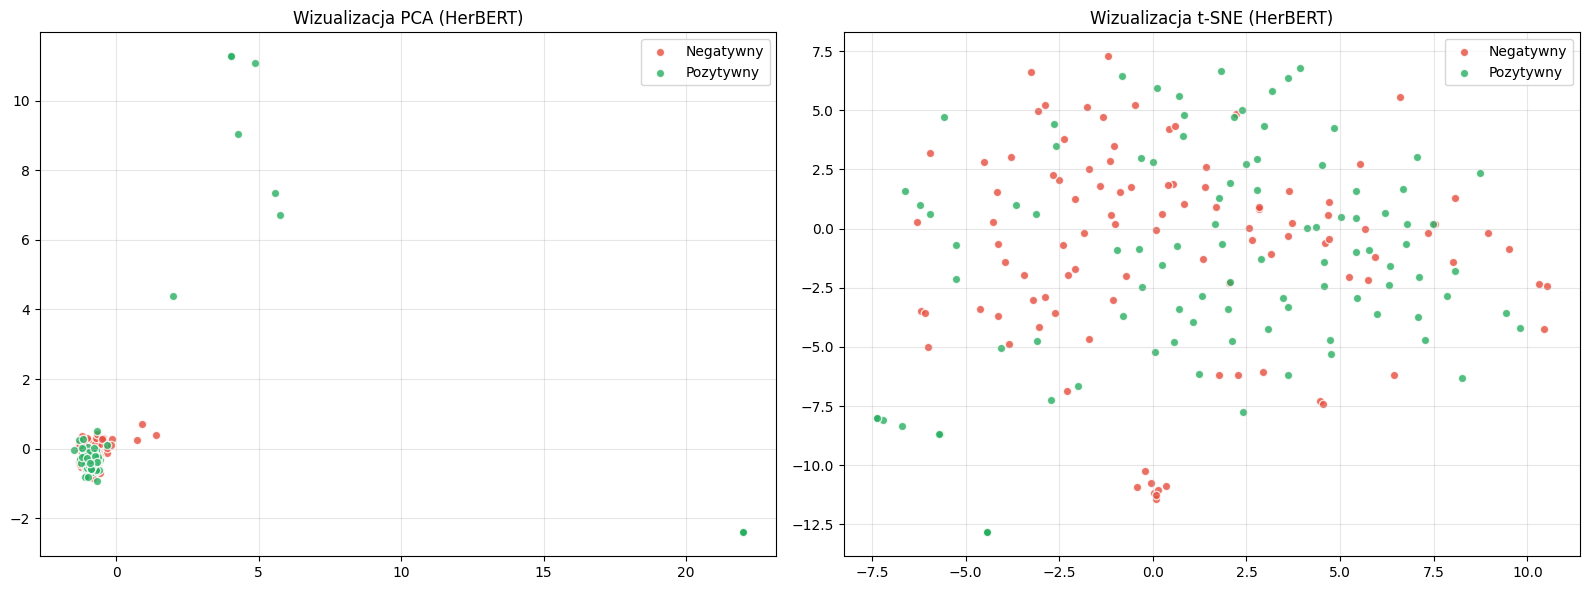

In [11]:
# PCA
pca = PCA(n_components=2, random_state=42)
coords_pca = pca.fit_transform(embeddings)
df_sample["pca_x"] = coords_pca[:, 0]
df_sample["pca_y"] = coords_pca[:, 1]

# t-SNE
tsne = TSNE(n_components=2, random_state=42)
coords_tsne = tsne.fit_transform(embeddings)
df_sample["tsne_x"] = coords_tsne[:, 0]
df_sample["tsne_y"] = coords_tsne[:, 1]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
colors_map = {"pozytywny": "#27ae60", "negatywny": "#e74c3c"}

for sentiment, group in df_sample.groupby("sentiment"):
    ax1.scatter(group["pca_x"], group["pca_y"], c=colors_map[sentiment], label=sentiment.capitalize(), alpha=0.8, edgecolor="white")
ax1.set_title("Wizualizacja PCA (HerBERT)")
ax1.legend()
ax1.grid(True, alpha=0.3)

for sentiment, group in df_sample.groupby("sentiment"):
    ax2.scatter(group["tsne_x"], group["tsne_y"], c=colors_map[sentiment], label=sentiment.capitalize(), alpha=0.8, edgecolor="white")
ax2.set_title("Wizualizacja t-SNE (HerBERT)")
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Zadanie 5: Podobieństwo semantyczne (Cosine Similarity)

**Komentarz:**
Analiza wyników pokazuje ciekawe zjawisko: średnie podobieństwo między klasami (POZ-NEG: 0.936) jest tu wyższe niż wewnątrz klasy pozytywnej (POZ-POZ: 0.915). Na heatmapie widać też jedno wyraźne zdanie-odstające (tzw. outlier - np. krótka recenzja ,,Polecam''), która wykazuje mniejsze podobieństwo (kolor niebieski) do reszty dłuższych opinii.

Wyniki te (wartości kosinusa na poziomie 0.9-1.0 dla niemal całej macierzy) są charakterystyczne dla surowych modeli BERT (tzw. anizotropia przestrzeni wektorowej). Embeddingi kodują tu ogólny kontekst i to, że wszystkie teksty są ,,recenzjami z Allegro'', a nie ich polaryzację. Udowadnia to, że choć embeddingi wychwytują sens języka, do poprawnej analizy sentymentu za ich pomocą potrzebna jest dodatkowa warstwa klasyfikująca (jak w Zadaniu 3), która ,,nauczy się'' odróżniać wydźwięk na podstawie wygenerowanych wektorów.

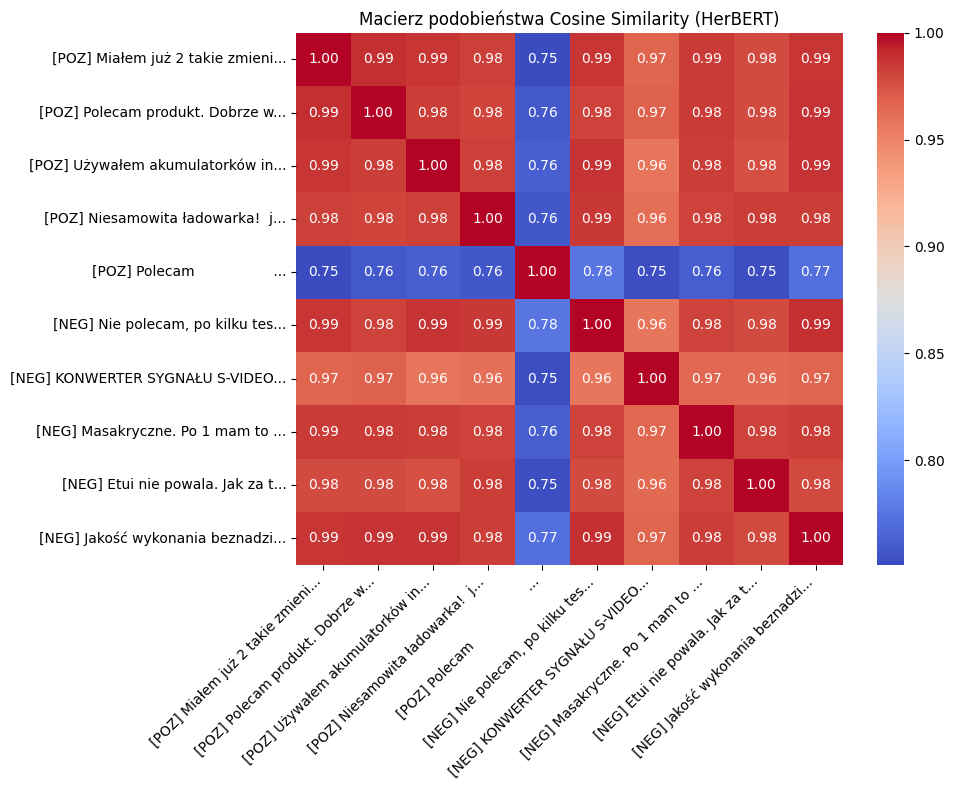

Średnie podobieństwo Pozytywne-Pozytywne: 0.915
Średnie podobieństwo Negatywne-Negatywne: 0.980
Średnie podobieństwo Pozytywne-Negatywne: 0.936


In [12]:
pos_idx = df_sample[df_sample["sentiment"] == "pozytywny"].head(5).index
neg_idx = df_sample[df_sample["sentiment"] == "negatywny"].head(5).index

selected_idx = list(pos_idx) + list(neg_idx)
selected_embeddings = embeddings[selected_idx]
selected_texts = df_sample.loc[selected_idx, "text"].tolist()
selected_labels = df_sample.loc[selected_idx, "sentiment"].tolist()

sim_matrix = cosine_similarity(selected_embeddings)

axis_labels = [f"[{lbl[:3].upper()}] {txt[:25]}..." for lbl, txt in zip(selected_labels, selected_texts)]

plt.figure(figsize=(10, 8))
sns.heatmap(sim_matrix, xticklabels=axis_labels, yticklabels=axis_labels, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Macierz podobieństwa Cosine Similarity (HerBERT)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"Średnie podobieństwo Pozytywne-Pozytywne: {sim_matrix[0:5, 0:5].mean():.3f}")
print(f"Średnie podobieństwo Negatywne-Negatywne: {sim_matrix[5:10, 5:10].mean():.3f}")
print(f"Średnie podobieństwo Pozytywne-Negatywne: {sim_matrix[0:5, 5:10].mean():.3f}")

### Wnioski

1. **Reprezentacja tekstu ma kluczowe znaczenie:** Zastosowanie odpowiedniej metody preprocessingu (Stemming, Lematyzacja) zredukowało wielkość słownika o ponad 30%, co wpływa pozytywnie na wydajność obliczeniową algorytmów klasycznych.
2. **Stemming vs Lematyzacja:** Lematyzacja sprowadza słowa do poprawnej formy słownikowej, radząc sobie z czasownikami czy deklinacją. Stemming jest szybki, ale ucinając końcówki bez analizy kontekstu, tworzy nieistniejące w języku słowa (np. zadowolon).
3. **Specyfika Embeddingów (HerBERT):** W przeciwieństwie do metod klasycznych (Bag of Words / TF-IDF), które szukają dokładnie tych samych słów, HerBERT koduje ogólne znaczenie tekstu (semantykę).
4. **Semantyka a Sentyment:** Wykresy (PCA/t-SNE) oraz macierz Cosine Similarity udowodniły, że bazowy (niedouczony) model językowy grupuje zdania pod kątem tematu i struktury, a nie wydźwięku emocjonalnego (sentymentu). Aby wektory te były w pełni użyteczne w klasyfikacji pozytywny/negatywny, konieczne jest nałożenie na nie dodatkowego klasyfikatora (np. regresji logistycznej), który wyciągnie z nich odpowiednie cechy decyzyjne.